# How to train your own word vector embeddings using Gensim

Many tasks require embeddings or domain-specific vocabulary that pre-trained models based on a generic corpus may not represent well or at all. Standard word2vec models are not able to assign vectors to out-of-vocabulary words and instead use a default vector that reduces their predictive value.

E.g., when working with industry-specific documents, the vocabulary or its usage may change over time as new technologies or products emerge. As a result, the embeddings need to evolve as well. In addition, corporate earnings releases use nuanced language not fully reflected in Glove vectors pre-trained on Wikipedia articles.

In this notebook we illustrate the more performant gensim adaptation of the code provided by the word2vec authors. 

To illustrate the word2vec network architecture, we use the Financial News data that we first introduced in chapter 14 on Topic Modeling. 

## Imports

In [1]:
%matplotlib inline 
import warnings
from time import time
from collections import Counter
from pathlib import Path
import pandas as pd
import numpy as np
from numpy.linalg import norm
from scipy.spatial.distance import cdist, cosine

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from gensim.models import Word2Vec, KeyedVectors
from gensim.models.word2vec import LineSentence
from sklearn.decomposition import IncrementalPCA

### Settings

In [2]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('float_format', '{:,.2f}'.format)
np.random.seed(42)

### Paths

In [4]:
news_path = Path('C:/','data','01-algo-trading','results', 'financial_news')
print(news_path)

C:\data\01-algo-trading\results\financial_news


In [5]:
data_path    = news_path / 'data'
analogy_path = Path('data', 'analogies-en.txt')

print(data_path)
print(analogy_path)

C:\data\01-algo-trading\results\financial_news\data
data\analogies-en.txt


In [6]:
def format_time(t):
    m, s = divmod(t, 60)
    h, m = divmod(m, 60)
    return f'{h:02.0f}:{m:02.0f}:{s:02.0f}'

## Model Configuration

In [7]:
gensim_path = news_path / 'gensim'
if not gensim_path.exists():
    gensim_path.mkdir(parents=True, exist_ok=True)

In [8]:
NGRAMS = 3           # Longest ngram in text
MIN_FREQ = 100
WINDOW_SIZE = 5
EMBEDDING_SIZE = 300
NEGATIVE_SAMPLES = 20
EPOCHS = 1

In [9]:
FILE_NAME = f'articles_{NGRAMS}_grams.txt'

## Sentence Generator

In [13]:
sentence_path = news_path / FILE_NAME
sentences = LineSentence(str(sentence_path))

## Train word2vec Model

In [14]:
from time import time
from gensim.models import Word2Vec

start = time()

model = Word2Vec(
    sentences=sentences,
    sg=1,                         # 1 = Skip-gram; 0 = CBOW
    vector_size=EMBEDDING_SIZE,    # formerly: size
    window=WINDOW_SIZE,
    min_count=MIN_FREQ,
    negative=NEGATIVE_SAMPLES,
    workers=8,
    epochs=EPOCHS,                 # formerly: iter
    alpha=0.05
)

# persist full model
model.save(str(gensim_path / "word2vec.model"))

# persist only the word vectors in Gensim KeyedVectors format
model.wv.save(str(gensim_path / "word_vectors.kv"))

print("Duration:", format_time(time() - start))

Duration: 00:18:21


## Evaluate results

In [15]:
cat_dict = {'capital-common-countries':'Capitals',
            'capital-world':'Capitals RoW',
            'city-in-state':'City-State',
            'currency':'Currency',
            'family':'Famliy',
            'gram1-adjective-to-adverb':'Adj-Adverb',
            'gram2-opposite':'Opposite',
            'gram3-comparative':'Comparative',
            'gram4-superlative':'Superlative',
            'gram5-present-participle':'Pres. Part.',
            'gram6-nationality-adjective':'Nationality',
            'gram7-past-tense':'Past Tense',
            'gram8-plural':'Plural',
            'gram9-plural-verbs':'Plural Verbs',
            'total':'Total'}

In [16]:
def accuracy_by_category_obs(acc, detail=True):
    results = [[c['section'], len(c['correct']), len(c['incorrect'])] for c in acc]
    results = pd.DataFrame(results, columns=['category', 'correct', 'incorrect'])
    results['average'] = results.correct.div(results[['correct', 'incorrect']].sum(1))
    if detail:
        print(results.sort_values('average', ascending=False))
    return results.loc[results.category=='total', ['correct', 'incorrect', 'average']].squeeze().tolist()

In [20]:
def accuracy_by_category(acc, detail=True):
    """
    Compute analogy accuracy by category from Gensim's evaluate_word_analogies output.

    Parameters
    ----------
    acc : list of dict
        Output returned by model.wv.evaluate_word_analogies(...)[1].
        Each element should contain:
        - 'section'
        - 'correct'
        - 'incorrect'

    detail : bool
        If True, print category-level accuracy.

    Returns
    -------
    list
        [total_correct, total_incorrect, total_accuracy]
    """

    results = []

    for category in acc:
        section_name = category["section"]
        n_correct = len(category["correct"])
        n_incorrect = len(category["incorrect"])

        results.append([
            section_name,
            n_correct,
            n_incorrect
        ])

    results = pd.DataFrame(
        results,
        columns=["category", "correct", "incorrect"]
    )

    results["total"] = results["correct"] + results["incorrect"]

    results["average"] = results["correct"].div(results["total"])

    if detail:
        print(results.sort_values("average", ascending=False))

    total_correct = results["correct"].sum()
    total_incorrect = results["incorrect"].sum()
    total_questions = total_correct + total_incorrect

    total_accuracy = (
        total_correct / total_questions
        if total_questions > 0
        else 0
    )

    return [
        total_correct,
        total_incorrect,
        total_accuracy
    ]

In [18]:
# gensim computes analogy accuracy based on source text files

overall_score, detailed_accuracy = model.wv.evaluate_word_analogies(
    analogy_path.as_posix(),
    case_insensitive=True
)

print("Overall analogy accuracy:", overall_score)

Overall analogy accuracy: 0.3102957283680175


In [21]:
# get accuracy per category
summary = accuracy_by_category(detailed_accuracy)
print('Base Accuracy: Correct {:,.0f} | Wrong {:,.0f} | Avg {:,.2%}\n'.format(*summary))

                       category  correct  incorrect  total  average
10  gram6-nationality-adjective      749        307   1056     0.71
0      capital-common-countries      293        127    420     0.70
1                 capital-world      608        582   1190     0.51
7             gram3-comparative      305        625    930     0.33
14               Total accuracy     2833       6297   9130     0.31
11             gram7-past-tense      341        849   1190     0.29
4                        family       35         97    132     0.27
8             gram4-superlative       59        247    306     0.19
12                 gram8-plural       50        256    306     0.16
9      gram5-present-participle       91        509    600     0.15
3                      currency       26        152    178     0.15
13           gram9-plural-verbs       73        433    506     0.14
2                 city-in-state      168       1476   1644     0.10
5     gram1-adjective-to-adverb       28        

In [22]:
most_sim = model.wv.most_similar(positive=['woman', 'king'], negative=['man'], topn=20)
pd.DataFrame(most_sim, columns=['token', 'similarity'])

,token,similarity
0,howell,0.43
1,teresa,0.43
2,pamela,0.41
3,louise,0.41
4,berger,0.41
5,keller,0.41
6,anderson,0.40
7,watson,0.40
8,bobby,0.40
9,alfred,0.40


In [25]:
counter = Counter(sentence_path.read_text(encoding="utf-8").split())

In [26]:
most_common = pd.DataFrame(counter.most_common(), columns=['token', 'count'])
most_common = most_common[most_common['count']> MIN_FREQ]
most_common['p'] = np.log(most_common['count'])/np.log(most_common['count']).sum()

In [27]:
similars = pd.DataFrame()
for token in np.random.choice(most_common.token, size=10, p=most_common.p):
    similars[token] = [s[0] for s in model.wv.most_similar(token)]
similars.T

,0,1,2,3,4,5,6,7,8,9
statistical,summarizes,unaudited_pro_forma,secondary_endpoints,tables_set_forth,metrics,mar_dec_sep_jun,biomarker,nearest_comparable,subset,definitions_reconciliations
cao,pamela,cunningham,jackie,diaz,jenny,erica,laurie,evp_cfo,kathryn,courtney
abs,cmbs,securitized,clo,agency_mbs,fundings,residential_mortgages,rmbs,refinancings,gse,afs
industrial_real_estate,owns_manages,publicly_traded_real_estate,commercial_real_estate,managed_real_estate,agricultural_real_estate,cre,multifamily,residential_real_estate,real_estate,owner_occupied
faces,facing,face,faced,posed,fend,poses,embattled,rivalry,loom,related_coverage_factbox
break,broke,broken,mess,savona,appease,fissure,stalemate,magma,spiral,babchenko
industries,sectors,industry,coolisys,industrial,sector,geospatial,automotive,verticals,packaged_goods,aerospace_defense
ce,nordson,hci,sci,redwood_city_calif,diagnostic_imaging,orthopedics,ce_mark,vtech,hcl,ultrasound
speeches,applause,appearances,aired,jokes,playbook,tonight,tweeting,joked,praising,loud
sogou,momo,bitauto,baozun,himax_technologies,jupai,nexstar,engility,leju,yintech,belden


## Continue Training

In [29]:
accuracies = [summary]
best_accuracy = summary[-1]

for i in range(1, 10):

    start = time()

    # Continue training the existing model for one additional epoch
    model.train(
        sentences,
        epochs=1,
        total_examples=model.corpus_count
    )

    # Gensim 4.x replacement for the old model.wv.accuracy(...)
    overall_score, detailed_accuracy = model.wv.evaluate_word_analogies(
        analogy_path.as_posix(),
        case_insensitive=True,
        restrict_vocab=300000,
        dummy4unknown=False
    )

    # Convert detailed analogy results into [correct, wrong, average]
    current_summary = accuracy_by_category(
        detailed_accuracy,
        detail=False
    )

    accuracies.append(current_summary)

    print(
        f"{i:02} | "
        f"Duration: {format_time(time() - start)} | "
        f"Accuracy: {accuracies[-1][-1]:.2%}"
    )

    # Save model only if accuracy improves
    if accuracies[-1][-1] > best_accuracy:

        model.save(
            str(gensim_path / f"word2vec_{i:02}.model")
        )

        # Save vectors in native Gensim KeyedVectors format
        model.wv.save(
            str(gensim_path / f"word_vectors_{i:02}.kv")
        )

        best_accuracy = accuracies[-1][-1]

    # Persist accuracy history after each epoch
    (
        pd.DataFrame(
            accuracies,
            columns=["correct", "wrong", "average"]
        )
        .to_csv(gensim_path / "accuracies.csv", index=False)
    )

# Save final vectors
model.wv.save(str(gensim_path / "word_vectors_final.kv"))

01 | Duration: 00:09:17 | Accuracy: 37.32%
02 | Duration: 00:09:07 | Accuracy: 38.82%
03 | Duration: 00:10:05 | Accuracy: 39.08%
04 | Duration: 00:10:44 | Accuracy: 38.05%
05 | Duration: 00:10:46 | Accuracy: 38.30%
06 | Duration: 00:09:24 | Accuracy: 38.83%
07 | Duration: 00:11:13 | Accuracy: 39.46%
08 | Duration: 00:11:33 | Accuracy: 39.15%
09 | Duration: 00:12:51 | Accuracy: 39.15%


## Evaluate Best Model

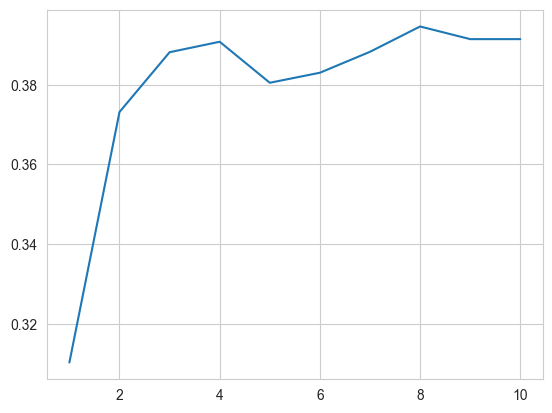

In [32]:
pd.DataFrame(accuracies, columns=['correct', 'wrong', 'average'], index=list(range(1, len(accuracies) + 1))).average.plot();

In [34]:
best_model = Word2Vec.load((gensim_path / 'word2vec_07.model').as_posix())

In [36]:
# new Gensim 4.x style
overall_score, detailed_accuracy = best_model.wv.evaluate_word_analogies(
    analogy_path.as_posix(),
    case_insensitive=True,
    restrict_vocab=300000,
    dummy4unknown=False
)

In [37]:
# get accuracy per category
summary = accuracy_by_category(detailed_accuracy)
print('Base Accuracy: Correct {:,.0f} | Wrong {:,.0f} | Avg {:,.2%}\n'.format(*summary))

                       category  correct  incorrect  total  average
0      capital-common-countries      341         79    420     0.81
10  gram6-nationality-adjective      790        266   1056     0.75
1                 capital-world      810        380   1190     0.68
14               Total accuracy     3603       5527   9130     0.39
7             gram3-comparative      335        595    930     0.36
11             gram7-past-tense      371        819   1190     0.31
2                 city-in-state      507       1137   1644     0.31
4                        family       36         96    132     0.27
12                 gram8-plural       72        234    306     0.24
8             gram4-superlative       67        239    306     0.22
9      gram5-present-participle      116        484    600     0.19
3                      currency       32        146    178     0.18
13           gram9-plural-verbs       78        428    506     0.15
5     gram1-adjective-to-adverb       35        

In [39]:
results = [[c['section'], len(c['correct']), len(c['incorrect'])] for c in detailed_accuracy]
results = pd.DataFrame(results, columns=['category', 'correct', 'incorrect'])
results['category'] = results.category.map(cat_dict)
results['average'] = results.correct.div(results[['correct', 'incorrect']].sum(1))
results = results.rename(columns=str.capitalize).set_index('Category')
#total = results.loc['Total']
#results = results.drop('Total')

In [40]:
most_sim = best_model.wv.most_similar(positive=['woman', 'king'], negative=['man'], topn=20)
pd.DataFrame(most_sim, columns=['token', 'similarity'])

,token,similarity
0,catherine,0.40
1,vernon,0.38
2,smith,0.37
3,director,0.36
4,jackson,0.36
5,howard,0.36
6,james,0.36
7,rogers,0.35
8,mason,0.35
9,queen_elizabeth,0.35


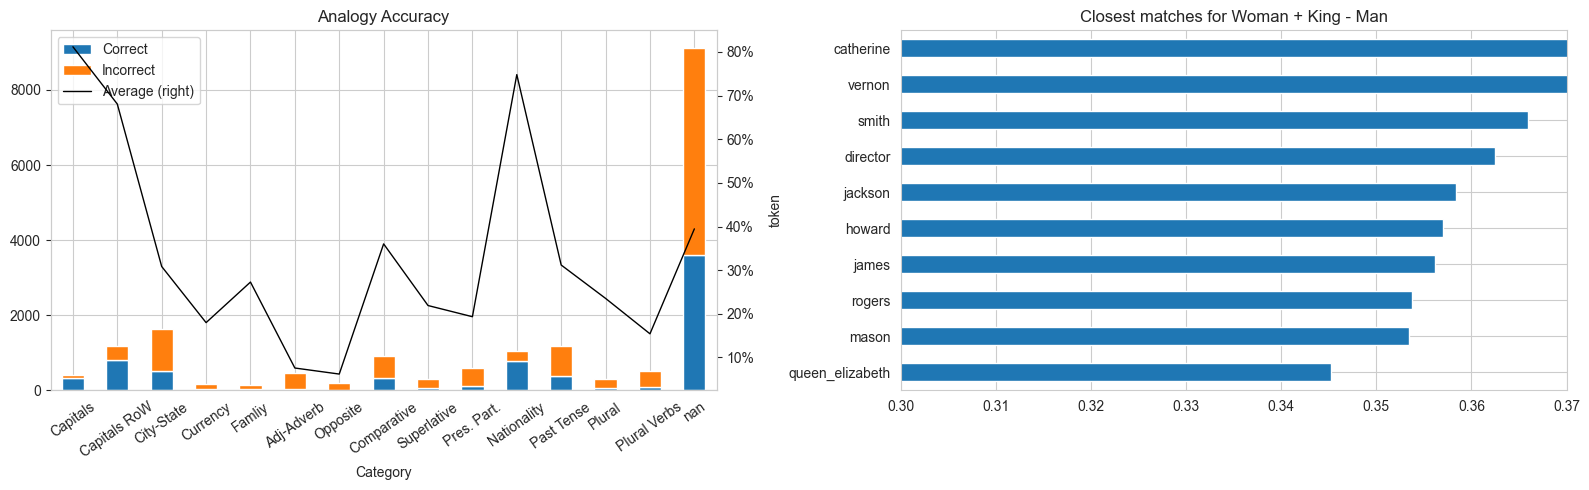

In [41]:
fig, axes = plt.subplots(figsize=(16, 5), ncols=2)

axes[0] = results.loc[:, ['Correct', 'Incorrect']].plot.bar(stacked=True, ax=axes[0]
                                                           , title='Analogy Accuracy')
ax1 = results.loc[:, ['Average']].plot(ax=axes[0], secondary_y=True, lw=1, c='k', rot=35)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

(pd.DataFrame(most_sim, columns=['token', 'similarity'])
 .set_index('token').similarity
 .sort_values().tail(10).plot.barh(xlim=(.3, .37), ax=axes[1], title='Closest matches for Woman + King - Man'))
fig.tight_layout();

In [43]:
counter = Counter(sentence_path.read_text(encoding='utf-8').split())

In [44]:
most_common = pd.DataFrame(counter.most_common(), columns=['token', 'count'])
most_common = most_common[most_common['count']> MIN_FREQ]
most_common['p'] = np.log(most_common['count'])/np.log(most_common['count']).sum()

In [45]:
similars = pd.DataFrame()
for token in np.random.choice(most_common.token, size=10, p=most_common.p):
    similars[token] = [s[0] for s in best_model.wv.most_similar(token)]
similars.T

,0,1,2,3,4,5,6,7,8,9
credit,loan,revolving_credit_facility,borrowings,loans,unsecured_revolving,revolving,revolving_line,revolving_credit,debt,lenders
conventions,principles,practice,convention,standards,norms,society,ethics,respects,practices,exist
teradata,ncr,vonage,sunpower,synnex,symantec,idt,zix,cyberark,cisco,marriott_vacations
places,people,fortune_magazine,cities,weekend,home,imagine,there,country,ways,neighborhoods
ftse,index,blue_chip,germany_dax,stocks,blue_chip_ftse,gainers,stoxx,wall_street,pct,kit_rees
wide_range,wide_variety,variety,wide_array,broad_array,customized,specialized,diverse,array,multiple,broad
cautioned_place_undue_reliance,place_undue_reliance,readers_cautioned_place_undue,investors_place_undue,unduly_rely,speak_date_hereof,speak_date,carefully_evaluating,undue_reliance_placed,undertake_obligation_update_revise,speak_date_made
altice_usa,altice_nv,altice,t_mobile,sprint,cincinnati_bell,gci_liberty,inpixon,layne,teradata,globalstar
warren,steve,tom,jeff,mike,thomas,ken,joe,jon,jim,scott
sophisticated,tools,capabilities,customized,scalable,analytics,cutting_edge,specialized,automated,expertise,complex


In [47]:
similars.T.iloc[:5, :5].to_csv('figures/most_similar.csv')

## Resources

- [Distributed representations of words and phrases and their compositionality](http://papers.nips.cc/paper/5021-distributed-representations-of-words-and-phrases-and-their-compositionality.pdf)
- [Efficient estimation of word representations in vector space](https://arxiv.org/pdf/1301.3781.pdf?)
- [Sebastian Ruder's Blog](http://ruder.io/word-embeddings-1/)